In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [243]:
df = pd.read_csv('bank-full.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Q1. Descriptive Stats – Age

* Compute the mean, median, and standard deviation of customer ages.
    - Are customers’ ages normally distributed or skewed?

In [245]:
age_mean = round(df['age'].mean(),2)
age_median = df['age'].median()
age_std = round(df['age'].std(),2)
age_skew = round(df['age'].skew(),2)

print(age_mean)
print(age_median)
print(age_std)
print(age_skew)

40.94
39.0
10.62
0.68


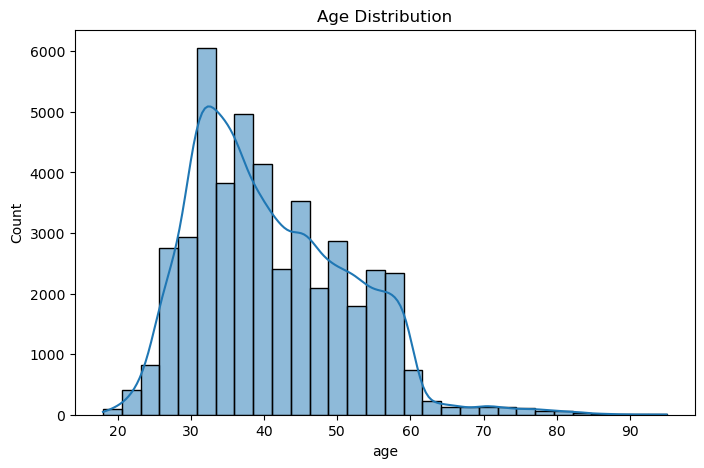

In [246]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

## Q2. Categorical Distribution – Job

* Calculate the proportion of customers in each job category.
    - Which job group is most represented?

In [248]:
job_count = df['job'].value_counts().reset_index(name = 'count')
job_count

,job,count
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154
5,retired,2264
6,self-employed,1579
7,entrepreneur,1487
8,unemployed,1303
9,housemaid,1240


In [249]:
job_proportion = df['job'].value_counts(normalize = True)* 100
job_proportion

job
blue-collar      21.525735
management       20.919688
technician       16.803433
admin.           11.437482
services          9.188029
retired           5.007631
self-employed     3.492513
entrepreneur      3.289023
unemployed        2.882042
housemaid         2.742695
student           2.074716
unknown           0.637013
Name: proportion, dtype: float64

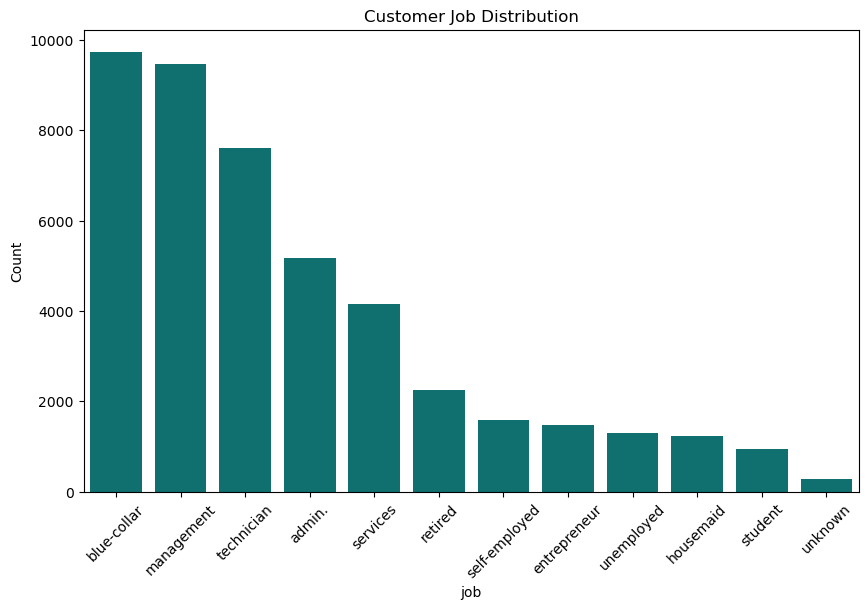

In [250]:
plt.figure(figsize=(10,6))
sns.barplot(x=job_count['job'], y=job_count['count'], color = 'teal')
plt.xticks(rotation=45)
plt.title("Customer Job Distribution")
plt.ylabel("Count")
plt.show()

## Q3. Campaign Analysis

* Test if the average number of contacts (campaign) differs between customers who subscribed (y = yes) and those who didn’t (y = no).
    - Use a t-test.

In [252]:
yes_df = df[df['y'] == 'yes']['campaign']
no_df = df[df['y'] == 'no']['campaign']

print("Mean (Subscribed):", yes_df.mean())
print("Mean (Not Subscribed):", no_df.mean())


Mean (Subscribed): 2.1410474569861977
Mean (Not Subscribed): 2.8463503832473322


In [253]:
from scipy import stats

print("Hypothesis Test:\n")
print("H0: No difference in average number of contacts (campaign) between subscribers and non-subscribers")
print("H1: There is a difference in average number of contacts.\n")

t_stat, p_val = stats.ttest_ind(yes_df, no_df)

print("T-statistic:", t_stat)
print("P-value:", p_val)

alpha = 0.05
if p_val < alpha:
    print("Conclusion: Reject H0 → There IS a statistically significant difference.")
else:
    print("Conclusion: Fail to reject H0 → No significant difference found.")

Hypothesis Test:

H0: No difference in average number of contacts (campaign) between subscribers and non-subscribers
H1: There is a difference in average number of contacts.

T-statistic: -15.599948860003783
P-value: 1.0123473642096295e-54
Conclusion: Reject H0 → There IS a statistically significant difference.


## Q4. Chi-Square Test – Education vs Subscription

* Perform a Chi-Square test of independence between education and y.
    - Is education level significantly associated with subscription?

In [255]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['education'], df['y'])
print("Contingency Table:\n", contingency)


Contingency Table:
 y             no   yes
education             
primary     6260   591
secondary  20752  2450
tertiary   11305  1996
unknown     1605   252


In [256]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-Square Test Results:")
print(f"Chi2 Statistic: {chi2:.3f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4f}")

print("\nHypothesis Test:")
print("H₀: Education and subscription outcome are independent (no association).")
print("H₁: Education and subscription outcome are associated.")

alpha = 0.05
if p < alpha:
    print("Conclusion: Reject H₀ → Education IS significantly associated with subscription outcome.")
else:
    print("Conclusion: Fail to reject H₀ → No significant association found.")



Chi-Square Test Results:
Chi2 Statistic: 238.924
Degrees of Freedom: 3
P-value: 0.0000

Hypothesis Test:
H₀: Education and subscription outcome are independent (no association).
H₁: Education and subscription outcome are associated.
Conclusion: Reject H₀ → Education IS significantly associated with subscription outcome.


## Q5. Correlation – Numerical Features

* Check correlations between age, balance, duration, campaign.
    - Which variable is most strongly correlated with subscription (y)?

In [258]:
corr_feat = df[['age', 'balance', 'duration', 'campaign']].corr()
print("Correlation matrix (features):\n")
corr_feat

Correlation matrix (features):



,age,balance,duration,campaign
age,1.000000,0.097783,-0.004648,0.004760
balance,0.097783,1.000000,0.021560,-0.014578
duration,-0.004648,0.021560,1.000000,-0.084570
campaign,0.004760,-0.014578,-0.084570,1.000000


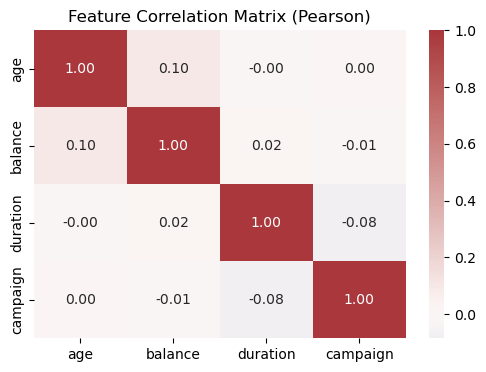

In [259]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_feat, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Feature Correlation Matrix (Pearson)")
plt.show()

## Q6. Hypothesis Test – Balance

* Test whether the average account balance of subscribers is significantly higher than that of non-subscribers.
    - Use a two-sample t-test.

In [261]:
subscribers_balance = df[df['y'] == 'yes']['balance']
non_subscribers_balance = df[df['y'] == 'no']['balance']

sub_mean = subscribers_balance.mean()
non_sub_mean = non_subscribers_balance.mean()

print("Mean balance (Subscribed):", round(sub_mean,2))
print("Mean balance (Not Subscribed):", round(non_sub_mean,2))

t_stat, p_value = stats.ttest_ind(subscribers_balance, non_subscribers_balance)

print("\nT-test Results:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value (two-tailed): {p_value:.4f}")

p_value_one_tailed = p_value / 2 if sub_mean > non_sub_mean else 1 - (p_value / 2)
print(f"P-value (one-tailed): {p_value_one_tailed:.4f}")

alpha = 0.05
if p_value_one_tailed < alpha:
    print("Conclusion: Reject H₀ → Subscribers have significantly higher balances.")
else:
    print("Conclusion: Fail to reject H₀ → No significant difference detected.")

Mean balance (Subscribed): 1804.27
Mean balance (Not Subscribed): 1303.71

T-test Results:
T-statistic: 11.250
P-value (two-tailed): 0.0000
P-value (one-tailed): 0.0000
Conclusion: Reject H₀ → Subscribers have significantly higher balances.


## Q7. Confidence Interval

* Compute a 95% confidence interval for the mean campaign duration (duration).
    - Interpret what this means.

In [263]:
mean_duration = df['duration'].mean()
std_duration = df['duration'].std()
n = len(df['duration'])

confidence = 0.95
alpha = 1-confidence
z_score = stats.norm.ppf(1-alpha/2)

margin_error = z_score * (std_duration/np.sqrt(n))
ci_lower = mean_duration - margin_error
ci_upper = mean_duration + margin_error

print(f"Mean duration: {mean_duration:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

Mean duration: 258.16
95% Confidence Interval: (255.79, 260.54)


## Q8. Odds Ratio – Marital Status

* Calculate the odds ratio of being subscribed (y = yes) for married vs single customers.
    - Does marital status affect likelihood of subscription?



In [265]:
contingency = pd.crosstab(df['marital'], df['y'])
print(contingency)

married_yes = contingency.loc['married', 'yes']
married_no  = contingency.loc['married', 'no']
single_yes  = contingency.loc['single', 'yes']
single_no   = contingency.loc['single', 'no']

odds_married = married_yes/married_no
odds_single = single_yes/single_no

odds_ratio = odds_married/odds_single

print("Odds (Married):", odds_married)
print("Odds (Single):", odds_single)
print("Odds Ratio:", odds_ratio)

y            no   yes
marital              
divorced   4585   622
married   24459  2755
single    10878  1912
Odds (Married): 0.11263747495809313
Odds (Single): 0.1757676043390329
Odds Ratio: 0.6408318266705738


## Q9. Logistic Relationship (EDA Style)

* Examine whether older customers (age > 50) have a significantly higher chance of subscribing compared to younger ones.
    - Run a proportion z-test.

In [267]:
from statsmodels.stats.proportion import proportions_ztest

In [268]:
older = df[df['age'] > 50]
younger = df[df['age'] <= 50]

nobs = np.array([len(older), len(younger)])
success = np.array([sum(older['y'] == 'yes'), sum(younger['y'] == 'yes')])

print("Older subscribed:", success[0], "out of", nobs[0])
print("Younger subscribed:", success[1], "out of", nobs[1])

stat, pval_two_tailed = proportions_ztest(success, nobs)

pval_one_tailed = pval_two_tailed / 2 if (success[0]/nobs[0] > success[1]/nobs[1]) else 1 - (pval_two_tailed/2)

print("Z-statistic:", stat)
print("One-tailed p-value:", pval_one_tailed)



Older subscribed: 1313 out of 9255
Younger subscribed: 3976 out of 35956
Z-statistic: 8.35225807514575
One-tailed p-value: 3.348506782727088e-17


## Q10. Outlier Detection

* Identify potential outliers in balance using the IQR method.
    - How do outliers affect the mean vs median balance?

In [270]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['balance'] < lower_bound) | (df['balance'] > upper_bound)]
print("Number of outliers:", len(outliers))


Number of outliers: 4729
